# 🌳 Árbol de Decisión CART — Clasificación Binaria de Misiones SpaceX

Construcción, entrenamiento y evaluación de un modelo de **Árbol de Decisión CART** para predecir
si una misión SpaceX será una **"Misión Pesada"** (`mision_pesada = 1`), definida como aquella
cuya carga útil total supera la mediana del dataset.

| | |
|---|---|
| **Variable objetivo (Y)** | `mision_pesada` (1 = carga > mediana, 0 = carga ≤ mediana) |
| **Variables predictoras (X)** | `payload_count`, `reused_cores`, `core_count`, `thrust_to_weight`, `isp_vacuum`, `cost_per_launch`, `rocket_mass_kg` |
| **Modelo** | `DecisionTreeClassifier` — criterio Gini (CART, scikit-learn) |
| **Estrategia de validación** | Tres splits: 80/20 · 70/30 · 60/40 + búsqueda de `max_depth` óptimo |
| **Balanceo** | Verificación + `resample` (oversampling) de la librería `sklearn.utils` |

> **Origen de datos** — Dataset sintético de 1500 misiones SpaceX (`np.random.seed(42)`), idéntico
> al utilizado en `regresion_lineal.ipynb`. El target binario se deriva discretizando
> `total_payload_mass` con la mediana como umbral.
> A diferencia de la Regresión Logística/Lineal, el árbol CART **no requiere escalado** de variables
> y mide la importancia de cada predictor mediante la **reducción de impureza Gini**.


## I. Configuración Inicial — Importaciones y Estilo Visual


In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.")


✅ Librerías importadas correctamente
   pandas   3.0.2
   numpy    2.4.4
   seaborn  0.13.2

⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.


## II. Generación de Datos Sintéticos SpaceX

Se mantiene **exactamente** la misma generación de datos del notebook `regresion_lineal.ipynb`
para garantizar continuidad entre ambos modelos.

- `np.random.seed(42)` → reproducibilidad
- `N = 1500` misiones simuladas
- 7 variables predictoras de ingeniería aeroespacial
- 1 variable continua original: `total_payload_mass` (kg)


In [2]:
# ── CELDA 2: Generación sintética idéntica a regresion_lineal.ipynb ──────────
np.random.seed(42)
N = 1500

payload_count    = np.random.choice([1, 2, 3, 4, 5], size=N, p=[0.75, 0.12, 0.07, 0.04, 0.02])
reused_cores     = np.random.choice([0, 1, 2], size=N, p=[0.36, 0.55, 0.09])
core_count       = np.random.choice([1, 2, 3], size=N, p=[0.92, 0.04, 0.04])
thrust_to_weight = np.random.uniform(50, 200, N)
isp_vacuum       = np.random.randint(290, 340, N)
cost_per_launch  = np.random.uniform(6_000_000, 100_000_000, N)
rocket_mass_kg   = np.random.uniform(30_000, 1_420_000, N)

noise = np.random.normal(0, 400, N)

total_payload_mass = (
      1_500  * reused_cores
    +    30  * thrust_to_weight
    +    10  * isp_vacuum
    +   200  * payload_count
    +   150  * (cost_per_launch / 1e7)
    - 4_500
    + noise
)

df = pd.DataFrame({
    'payload_count':      payload_count,
    'reused_cores':       reused_cores,
    'core_count':         core_count,
    'thrust_to_weight':   thrust_to_weight,
    'isp_vacuum':         isp_vacuum,
    'cost_per_launch':    cost_per_launch,
    'rocket_mass_kg':     rocket_mass_kg,
    'total_payload_mass': total_payload_mass,
})

print(f"✅ Dataset generado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n📊 total_payload_mass (variable continua original):")
print(f"   min     : {df['total_payload_mass'].min():>8.0f} kg")
print(f"   max     : {df['total_payload_mass'].max():>8.0f} kg")
print(f"   media   : {df['total_payload_mass'].mean():>8.0f} kg")
print(f"   mediana : {df['total_payload_mass'].median():>8.0f} kg")
df.head()


✅ Dataset generado: 1,500 filas × 8 columnas

📊 total_payload_mass (variable continua original):
   min     :      219 kg
   max     :     9983 kg
   media   :     4562 kg
   mediana :     4535 kg


,payload_count,reused_cores,core_count,thrust_to_weight,isp_vacuum,cost_per_launch,rocket_mass_kg,total_payload_mass
0,1,1,1,139.894893,322,3.582236e+07,655632.423341,5955.153214
1,4,1,1,127.056178,290,7.803258e+07,60766.886931,5559.145522
2,1,0,1,93.227679,294,5.280717e+07,920587.212371,2373.028297
3,1,0,1,50.969654,302,3.514320e+07,605357.220693,992.766102
4,1,1,1,124.435883,308,8.232497e+07,405381.267881,4847.699266


## III. Discretización — Creación de la Variable Binaria

Se transforma `total_payload_mass` (continua) en `mision_pesada` (binaria) usando la **mediana**
como umbral. Esto convierte el problema de regresión original en uno de **clasificación binaria**:

$$\text{mision\_pesada} = \begin{cases} 1 & \text{si } \text{total\_payload\_mass} > \text{mediana} \\ 0 & \text{en otro caso} \end{cases}$$

**¿Por qué la mediana?** Garantiza un balance natural cercano a 50/50, ideal para árboles de decisión.


📌 Umbral de discretización (mediana): 4,535 kg

Balance de la variable objetivo:
   Misión PESADA (1) :   750  (50.0%)
   Misión LIGERA (0) :   750  (50.0%)


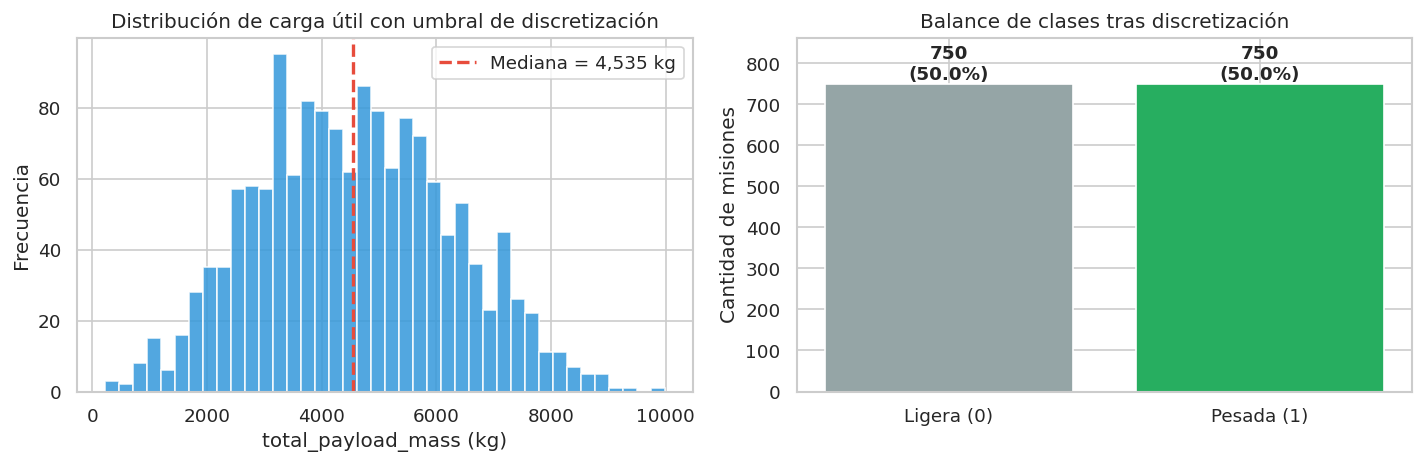

In [3]:
# ── CELDA 3: Crear target binario `mision_pesada` ────────────────────────────
umbral = df['total_payload_mass'].median()
df['mision_pesada'] = (df['total_payload_mass'] > umbral).astype(int)

print(f"📌 Umbral de discretización (mediana): {umbral:,.0f} kg\n")

bal = df['mision_pesada'].value_counts()
pct = df['mision_pesada'].value_counts(normalize=True) * 100
print("Balance de la variable objetivo:")
print(f"   Misión PESADA (1) : {bal[1]:>5,}  ({pct[1]:.1f}%)")
print(f"   Misión LIGERA (0) : {bal[0]:>5,}  ({pct[0]:.1f}%)")

# Visualización del balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con umbral
axes[0].hist(df['total_payload_mass'], bins=40, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(umbral, color='#e74c3c', linestyle='--', lw=2, label=f'Mediana = {umbral:,.0f} kg')
axes[0].set_xlabel('total_payload_mass (kg)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de carga útil con umbral de discretización')
axes[0].legend()

# Barras de balance
colors = ['#95a5a6', '#27ae60']
bars = axes[1].bar(['Ligera (0)', 'Pesada (1)'], [bal[0], bal[1]], color=colors, edgecolor='white')
axes[1].set_ylabel('Cantidad de misiones')
axes[1].set_title('Balance de clases tras discretización')
for bar, valor, p in zip(bars, [bal[0], bal[1]], [pct[0], pct[1]]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{valor:,}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[1].set_ylim(0, max(bal) * 1.15)

plt.tight_layout()
plt.show()


## IV. Verificación de Balance y Aplicación de `resample`

### Estrategia de balanceo

Se evalúa el ratio de la clase minoritaria:

| Ratio minoritaria | Acción |
|---|---|
| ≥ 40% | Dataset **balanceado** → resample se aplica de forma **demostrativa** (no altera resultados) |
| < 40% | Dataset **desbalanceado** → se aplica **oversampling** real de la clase minoritaria |

> **Por qué oversampling y no undersampling**: con N=1500 perderíamos información eliminando registros.
> El oversampling con `resample(replace=True)` duplica aleatoriamente la clase minoritaria hasta
> igualar a la mayoritaria, conservando todos los datos originales.


In [4]:
# ── CELDA 4: Verificación de balance + resample ──────────────────────────────
conteo = df['mision_pesada'].value_counts()
ratio_minoritaria = conteo.min() / conteo.sum()

print(f"📊 Diagnóstico de balance:")
print(f"   Ratio clase minoritaria: {ratio_minoritaria:.3f}")

if ratio_minoritaria < 0.40:
    print("   ⚠️  Desbalance detectado → se aplicará OVERSAMPLING real")
    es_demostrativo = False
else:
    print("   ✅ Dataset balanceado → resample será DEMOSTRATIVO (no altera resultados)")
    es_demostrativo = True

# Identificar clases (independiente del orden de pandas)
conteo_clases = df['mision_pesada'].value_counts()
clase_mayoritaria = conteo_clases.index[0]
clase_minoritaria = conteo_clases.index[-1]

df_mayoritaria = df[df['mision_pesada'] == clase_mayoritaria]
df_minoritaria = df[df['mision_pesada'] == clase_minoritaria]

print(f"\n   Clase mayoritaria = {clase_mayoritaria} → {len(df_mayoritaria):,} muestras")
print(f"   Clase minoritaria = {clase_minoritaria} → {len(df_minoritaria):,} muestras")

# Oversampling con sklearn.utils.resample
if clase_mayoritaria != clase_minoritaria:
    df_minoritaria_oversampled = resample(
        df_minoritaria,
        replace=True,                           # con reposición (duplica)
        n_samples=len(df_mayoritaria),          # igualar a la mayoritaria
        random_state=42
    )
    df_balanced = pd.concat([df_mayoritaria, df_minoritaria_oversampled])
else:
    # Balance perfecto: el resample no necesita actuar; lo mantenemos como demostración
    df_balanced = df.copy()

# Mezclar aleatoriamente
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ Tras aplicar resample:")
print(df_balanced['mision_pesada'].value_counts().to_string())
print(f"\n   Tamaño final del dataset: {len(df_balanced):,} filas")


📊 Diagnóstico de balance:
   Ratio clase minoritaria: 0.500
   ✅ Dataset balanceado → resample será DEMOSTRATIVO (no altera resultados)

   Clase mayoritaria = 1 → 750 muestras
   Clase minoritaria = 0 → 750 muestras

✅ Tras aplicar resample:
mision_pesada
0    750
1    750

   Tamaño final del dataset: 1,500 filas


## V. Preparación de X e y

Se definen las **7 variables predictoras** (idénticas a las de regresión lineal) y la
variable objetivo binaria.

> ⚠️  Se **excluye** `total_payload_mass` del set de features porque es exactamente la variable
> que originó el target — incluirla causaría **data leakage** (el modelo aprendería la regla trivial
> "es pesada si total_payload_mass > mediana" con accuracy = 100%, sin valor predictivo real).


In [5]:
# ── CELDA 5: Definir X e y ────────────────────────────────────────────────────
features = [
    'payload_count', 'reused_cores', 'core_count',
    'thrust_to_weight', 'isp_vacuum',
    'cost_per_launch', 'rocket_mass_kg'
]

X = df_balanced[features]
y = df_balanced['mision_pesada']

print("✅ Datos preparados para entrenamiento")
print(f"   X shape: {X.shape}  →  {len(features)} features")
print(f"   y shape: {y.shape}")
print(f"\n   Features: {features}")
print(f"\n   Distribución de clases en y:")
print(f"     0 (Ligera): {(y == 0).sum():,}")
print(f"     1 (Pesada): {(y == 1).sum():,}")
print("\n⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.")


✅ Datos preparados para entrenamiento
   X shape: (1500, 7)  →  7 features
   y shape: (1500,)

   Features: ['payload_count', 'reused_cores', 'core_count', 'thrust_to_weight', 'isp_vacuum', 'cost_per_launch', 'rocket_mass_kg']

   Distribución de clases en y:
     0 (Ligera): 750
     1 (Pesada): 750

⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.


## VI. Entrenamiento y Evaluación — Tres Splits (80/20 · 70/30 · 60/40)

Para cada split se sigue el mismo proceso:
1. Dividir `X` e `y` en entrenamiento y prueba (con `stratify=y` para mantener proporción de clases)
2. Entrenar `DecisionTreeClassifier` con criterio Gini y `class_weight='balanced'`
3. Predecir sobre el conjunto de prueba
4. Calcular: **matriz de confusión, precision, recall, F1-score**, accuracy y ROC-AUC

### Hiperparámetros del árbol

| Parámetro | Valor | Razón |
|---|---|---|
| `criterion` | `'gini'` | Criterio CART estándar (Classification And Regression Trees) |
| `min_samples_split` | `10` | Evita divisiones en nodos con muy pocas muestras |
| `min_samples_leaf` | `5` | Hojas con al menos 5 muestras → menos overfitting |
| `class_weight` | `'balanced'` | Refuerzo extra de balance aunque ya aplicamos resample |
| `max_depth` | `None` (inicial) | Sin límite — se buscará el óptimo en la Sección VII |


In [6]:
# ── CELDA 6: Función reutilizable de entrenamiento + evaluación ─────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split", max_depth=None):
    """
    Entrena un DecisionTreeClassifier y devuelve un dict con todas las métricas.

    Métricas requeridas: matriz de confusión, precision, recall, F1-score.
    Métricas adicionales: accuracy y ROC-AUC para análisis comparativo.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    return {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'cm'        : cm,
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'")
print("   · stratify=y → preserva proporción de clases en train/test")


✅ Función `entrenar_evaluar` definida correctamente
   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'
   · stratify=y → preserva proporción de clases en train/test


In [7]:
# ── CELDA 7: Ejecutar los tres splits requeridos ─────────────────────────────
resultados = [
    entrenar_evaluar(X, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X, y, test_size=0.30, nombre="Split 70/30"),
    entrenar_evaluar(X, y, test_size=0.40, nombre="Split 60/40"),
]

# Tabla en consola
print("=" * 75)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART (SpaceX)':^75}")
print("=" * 75)
print(f"{'Split':<13} {'N Train':>8} {'N Test':>8} {'Acc':>8} {'Prec':>8} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 75)
for r in resultados:
    print(
        f"{r['nombre']:<13} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>8.4f} {r['precision']:>8.4f}"
        f" {r['recall']:>8.4f} {r['f1']:>8.4f} {r['roc_auc']:>8.4f}"
    )
print("=" * 75)


          MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART (SpaceX)          
Split          N Train   N Test      Acc     Prec   Recall       F1      AUC
---------------------------------------------------------------------------
Split 80/20      1,200      300   0.9100   0.9184   0.9000   0.9091   0.9555
Split 70/30      1,050      450   0.9044   0.9136   0.8933   0.9034   0.9520
Split 60/40        900      600   0.8767   0.8669   0.8900   0.8783   0.9378


## VII. Matrices de Confusión por Split

La matriz de confusión es una de las **métricas requeridas**. Muestra para cada split:

|              | Predicho: 0 (Ligera) | Predicho: 1 (Pesada) |
|---|---|---|
| **Real: 0** | Verdaderos Negativos (TN) | Falsos Positivos (FP) |
| **Real: 1** | Falsos Negativos (FN) | Verdaderos Positivos (TP) |

A partir de ellas se calculan directamente:
- $\text{Precision} = \dfrac{TP}{TP + FP}$
- $\text{Recall} = \dfrac{TP}{TP + FN}$
- $\text{F1} = 2 \cdot \dfrac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$


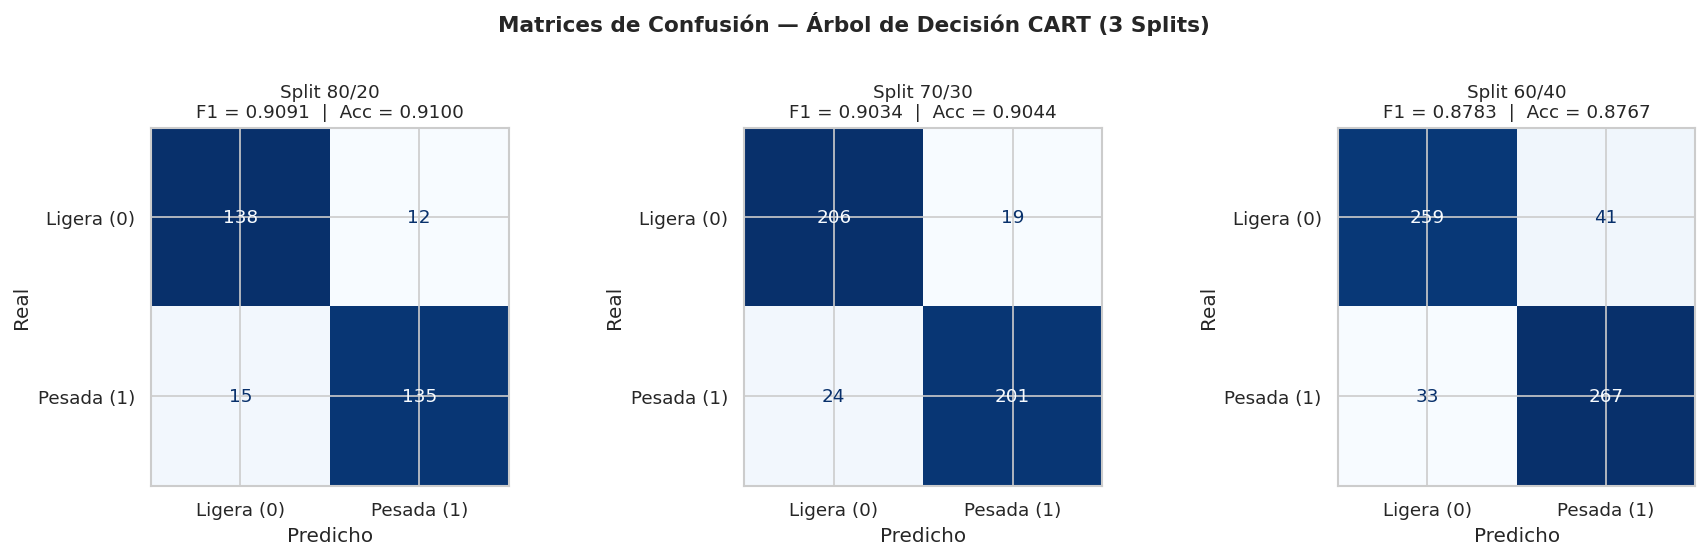


                    DESGLOSE DE LA MATRIZ DE CONFUSIÓN                     

📌 Split 80/20:
   TN (Verdadero Negativo) =  138    FP (Falso Positivo)  =   12
   FN (Falso Negativo)     =   15    TP (Verdadero Positivo)=  135
   → Precision = TP/(TP+FP) = 135/147 = 0.9184
   → Recall    = TP/(TP+FN) = 135/150 = 0.9000
   → F1-Score  = 0.9091

📌 Split 70/30:
   TN (Verdadero Negativo) =  206    FP (Falso Positivo)  =   19
   FN (Falso Negativo)     =   24    TP (Verdadero Positivo)=  201
   → Precision = TP/(TP+FP) = 201/220 = 0.9136
   → Recall    = TP/(TP+FN) = 201/225 = 0.8933
   → F1-Score  = 0.9034

📌 Split 60/40:
   TN (Verdadero Negativo) =  259    FP (Falso Positivo)  =   41
   FN (Falso Negativo)     =   33    TP (Verdadero Positivo)=  267
   → Precision = TP/(TP+FP) = 267/308 = 0.8669
   → Recall    = TP/(TP+FN) = 267/300 = 0.8900
   → F1-Score  = 0.8783


In [8]:
# ── CELDA 8: Matrices de confusión de los 3 splits ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Matrices de Confusión — Árbol de Decisión CART (3 Splits)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, r in zip(axes, resultados):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=r['cm'],
        display_labels=['Ligera (0)', 'Pesada (1)']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f"{r['nombre']}\nF1 = {r['f1']:.4f}  |  Acc = {r['accuracy']:.4f}",
                 fontsize=11)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

# Imprimir desglose detallado por split
print("\n" + "=" * 75)
print(f"{'DESGLOSE DE LA MATRIZ DE CONFUSIÓN':^75}")
print("=" * 75)
for r in resultados:
    tn, fp, fn, tp = r['cm'].ravel()
    print(f"\n📌 {r['nombre']}:")
    print(f"   TN (Verdadero Negativo) = {tn:>4}    FP (Falso Positivo)  = {fp:>4}")
    print(f"   FN (Falso Negativo)     = {fn:>4}    TP (Verdadero Positivo)= {tp:>4}")
    print(f"   → Precision = TP/(TP+FP) = {tp}/{tp+fp} = {r['precision']:.4f}")
    print(f"   → Recall    = TP/(TP+FN) = {tp}/{tp+fn} = {r['recall']:.4f}")
    print(f"   → F1-Score  = {r['f1']:.4f}")


## VIII. Reporte de Clasificación — Precision, Recall y F1 por Clase

`classification_report` de scikit-learn muestra las métricas requeridas **desglosadas por clase**,
incluyendo support (cantidad de muestras de cada clase en test).


In [9]:
# ── CELDA 9: Classification report por split ─────────────────────────────────
for r in resultados:
    print("=" * 70)
    print(f"  REPORTE DE CLASIFICACIÓN — {r['nombre']}")
    print("=" * 70)
    print(classification_report(
        r['y_test'], r['y_pred'],
        target_names=['Ligera (0)', 'Pesada (1)'],
        digits=4
    ))


  REPORTE DE CLASIFICACIÓN — Split 80/20
              precision    recall  f1-score   support

  Ligera (0)     0.9020    0.9200    0.9109       150
  Pesada (1)     0.9184    0.9000    0.9091       150

    accuracy                         0.9100       300
   macro avg     0.9102    0.9100    0.9100       300
weighted avg     0.9102    0.9100    0.9100       300

  REPORTE DE CLASIFICACIÓN — Split 70/30
              precision    recall  f1-score   support

  Ligera (0)     0.8957    0.9156    0.9055       225
  Pesada (1)     0.9136    0.8933    0.9034       225

    accuracy                         0.9044       450
   macro avg     0.9046    0.9044    0.9044       450
weighted avg     0.9046    0.9044    0.9044       450

  REPORTE DE CLASIFICACIÓN — Split 60/40
              precision    recall  f1-score   support

  Ligera (0)     0.8870    0.8633    0.8750       300
  Pesada (1)     0.8669    0.8900    0.8783       300

    accuracy                         0.8767       600
   ma

## IX. Búsqueda de Hiperparámetros — `max_depth` Óptimo

Se itera `max_depth` de 1 a 15 usando el split 80/20 para encontrar el punto donde el modelo
generaliza mejor sin sobreajustarse.

- **Underfitting** → `max_depth` muy pequeño: el árbol no captura la complejidad del problema.
- **Overfitting** → `max_depth` muy grande: el árbol memoriza el entrenamiento pero falla en test.
- **Óptimo** → donde la curva de F1-test alcanza su máximo.


🏆 Mejor max_depth según F1-Score en test: 8
   F1-Score test en depth=8: 0.9097


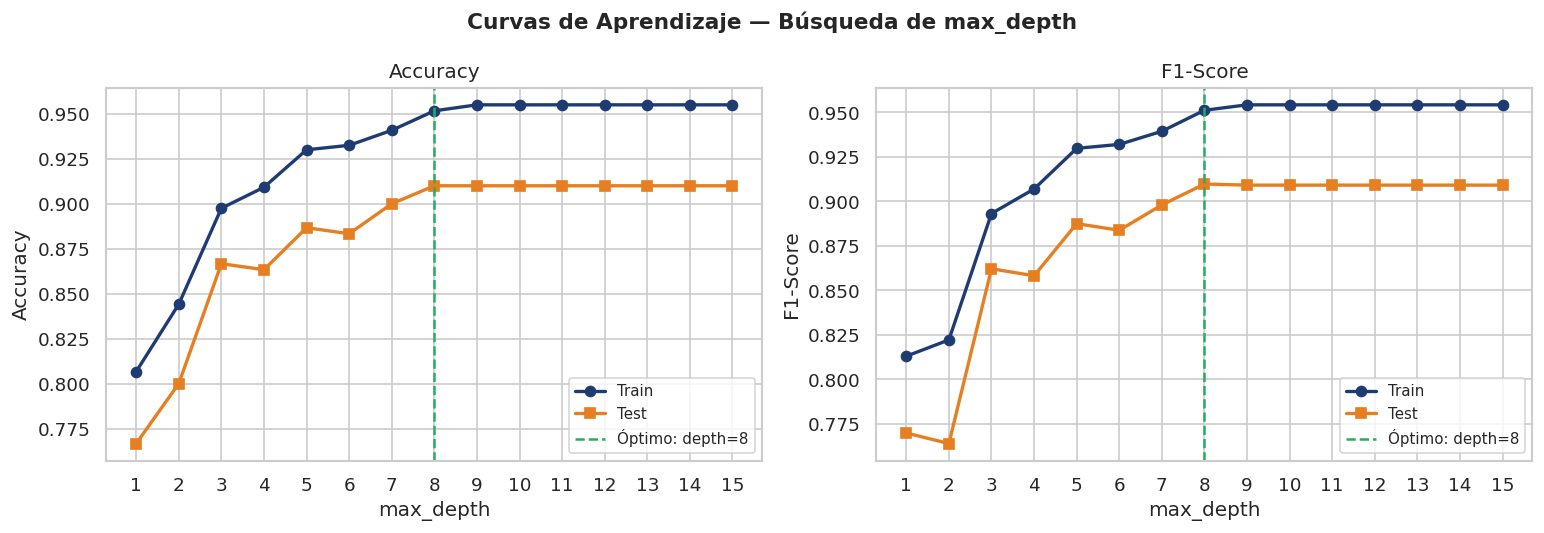

In [10]:
# ── CELDA 10: Búsqueda de max_depth óptimo ───────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

profundidades  = range(1, 16)
acc_train, acc_test   = [], []
f1_train,  f1_test    = [], []

for d in profundidades:
    m = DecisionTreeClassifier(
        criterion='gini', max_depth=d,
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42
    )
    m.fit(X_tr, y_tr)
    acc_train.append(accuracy_score(y_tr, m.predict(X_tr)))
    f1_train.append(f1_score(y_tr, m.predict(X_tr), zero_division=0))
    acc_test.append(accuracy_score(y_te, m.predict(X_te)))
    f1_test.append(f1_score(y_te, m.predict(X_te), zero_division=0))

mejor_depth = list(profundidades)[int(np.argmax(f1_test))]
print(f"🏆 Mejor max_depth según F1-Score en test: {mejor_depth}")
print(f"   F1-Score test en depth={mejor_depth}: {max(f1_test):.4f}")

# Gráfico de curvas
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Curvas de Aprendizaje — Búsqueda de max_depth',
             fontsize=13, fontweight='bold')

for ax, (titulo, train_vals, test_vals) in zip(axes, [
    ('Accuracy', acc_train, acc_test),
    ('F1-Score', f1_train, f1_test),
]):
    ax.plot(profundidades, train_vals, 'o-', color='#1e3c72', lw=2, label='Train')
    ax.plot(profundidades, test_vals,  's-', color='#e67e22', lw=2, label='Test')
    ax.axvline(x=mejor_depth, color='#27ae60', linestyle='--', lw=1.5,
               label=f'Óptimo: depth={mejor_depth}')
    ax.set_xlabel('max_depth')
    ax.set_ylabel(titulo)
    ax.set_title(titulo)
    ax.legend(fontsize=9)
    ax.set_xticks(list(profundidades))

plt.tight_layout()
plt.show()


## X. Visualizaciones — Curvas ROC y Métricas Comparativas


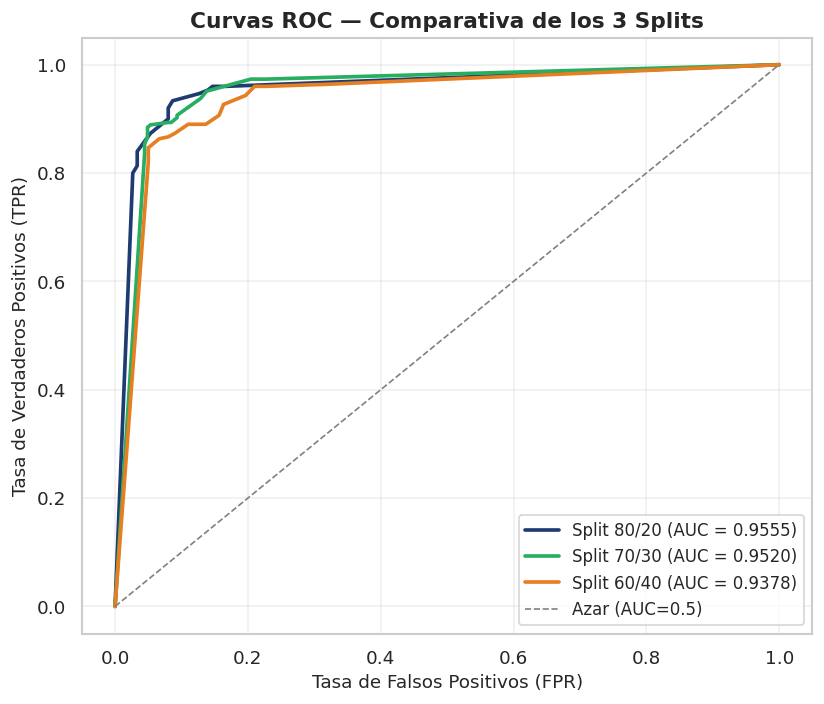

In [11]:
# ── CELDA 11: Curvas ROC comparativas ────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(7, 6))
for r, color in zip(resultados, COLORS):
    ax.plot(r['fpr'], r['tpr'], color=color, lw=2.2,
            label=f"{r['nombre']} (AUC = {r['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Azar (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curvas ROC — Comparativa de los 3 Splits', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


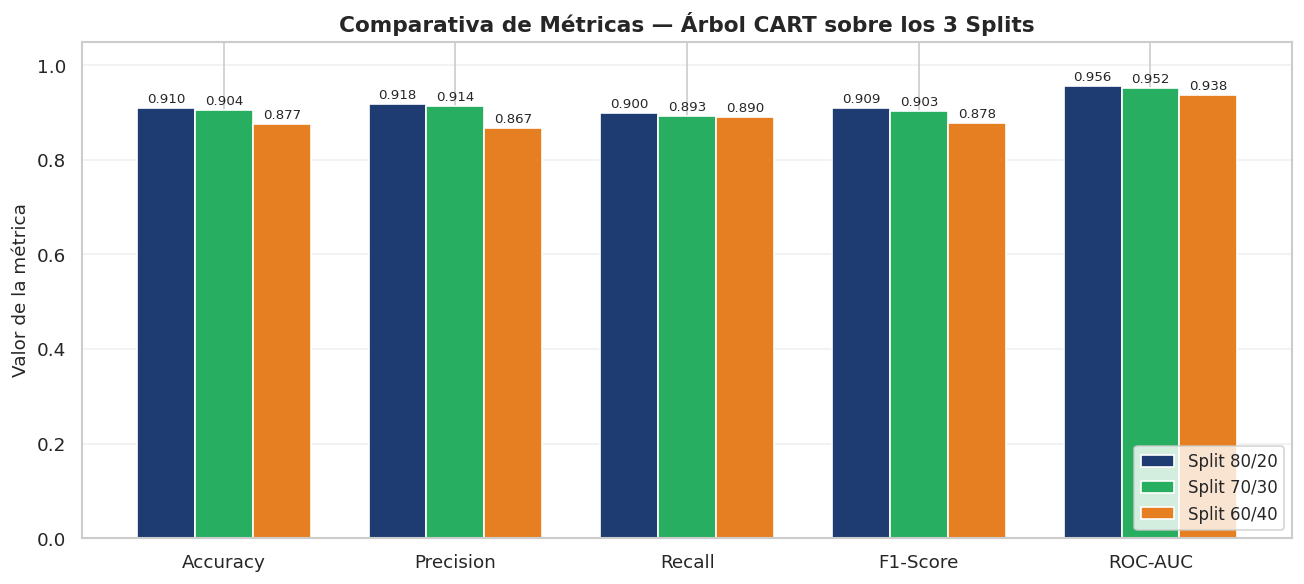

In [12]:
# ── CELDA 12: Gráfico de barras comparativo de métricas ──────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metricas_labels  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(metricas_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    valores = [r[m] for m in metricas_nombres]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, valores, width, label=r['nombre'], color=color, edgecolor='white')
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metricas_labels, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Valor de la métrica', fontsize=11)
ax.set_title('Comparativa de Métricas — Árbol CART sobre los 3 Splits',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## XI. Importancia de Variables — Feature Importance (Gini)

A diferencia de la Regresión Lineal/Logística (coeficientes lineales), el árbol CART mide la importancia
de cada variable mediante la **reducción promedio de impureza Gini** en todos los nodos donde se usó esa variable.

- Un valor mayor indica que la variable contribuye más a separar las clases.
- La suma de todas las importancias es igual a 1.0.
- Una variable con importancia **0** significa que el árbol nunca la utilizó para dividir.


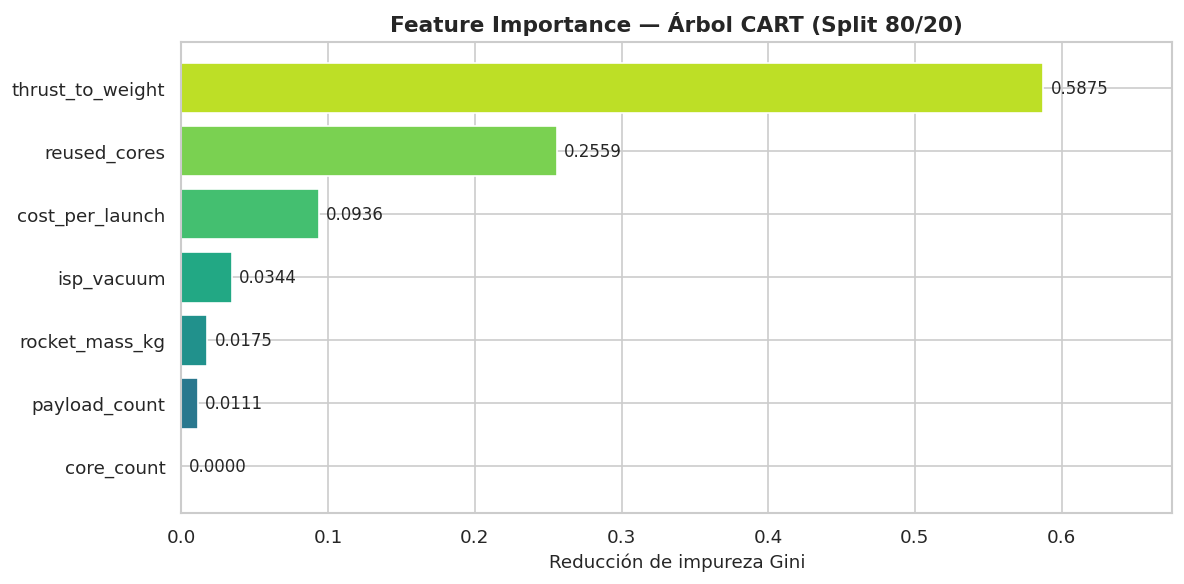


📊 Tabla de importancias (orden descendente):
thrust_to_weight    0.587454
reused_cores        0.255950
cost_per_launch     0.093617
isp_vacuum          0.034406
rocket_mass_kg      0.017483
payload_count       0.011091
core_count          0.000000


In [13]:
# ── CELDA 13: Importancia de variables (Feature Importance Gini) ────────────
modelo_ref = resultados[0]['modelo']   # usamos el split 80/20 como referencia
importancias = pd.Series(
    modelo_ref.feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors_imp = plt.cm.viridis(np.linspace(0.3, 0.9, len(importancias)))
ax.barh(importancias.index, importancias.values, color=colors_imp, edgecolor='white')
for i, (feat, val) in enumerate(zip(importancias.index, importancias.values)):
    ax.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Reducción de impureza Gini', fontsize=11)
ax.set_title('Feature Importance — Árbol CART (Split 80/20)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, max(importancias.values) * 1.15)
plt.tight_layout()
plt.show()

print("\n📊 Tabla de importancias (orden descendente):")
print(importancias.sort_values(ascending=False).to_string())


## XII. Visualización del Árbol de Decisión

Se reentrena con el `mejor_depth` encontrado en la Sección IX y se visualiza la estructura del árbol.
Cada nodo muestra:
- **Condición de división** (ej. `thrust_to_weight <= 124.5`)
- **Impureza Gini** del nodo
- **samples**: cantidad de muestras que llegan al nodo
- **value**: distribución [clase_0, clase_1]


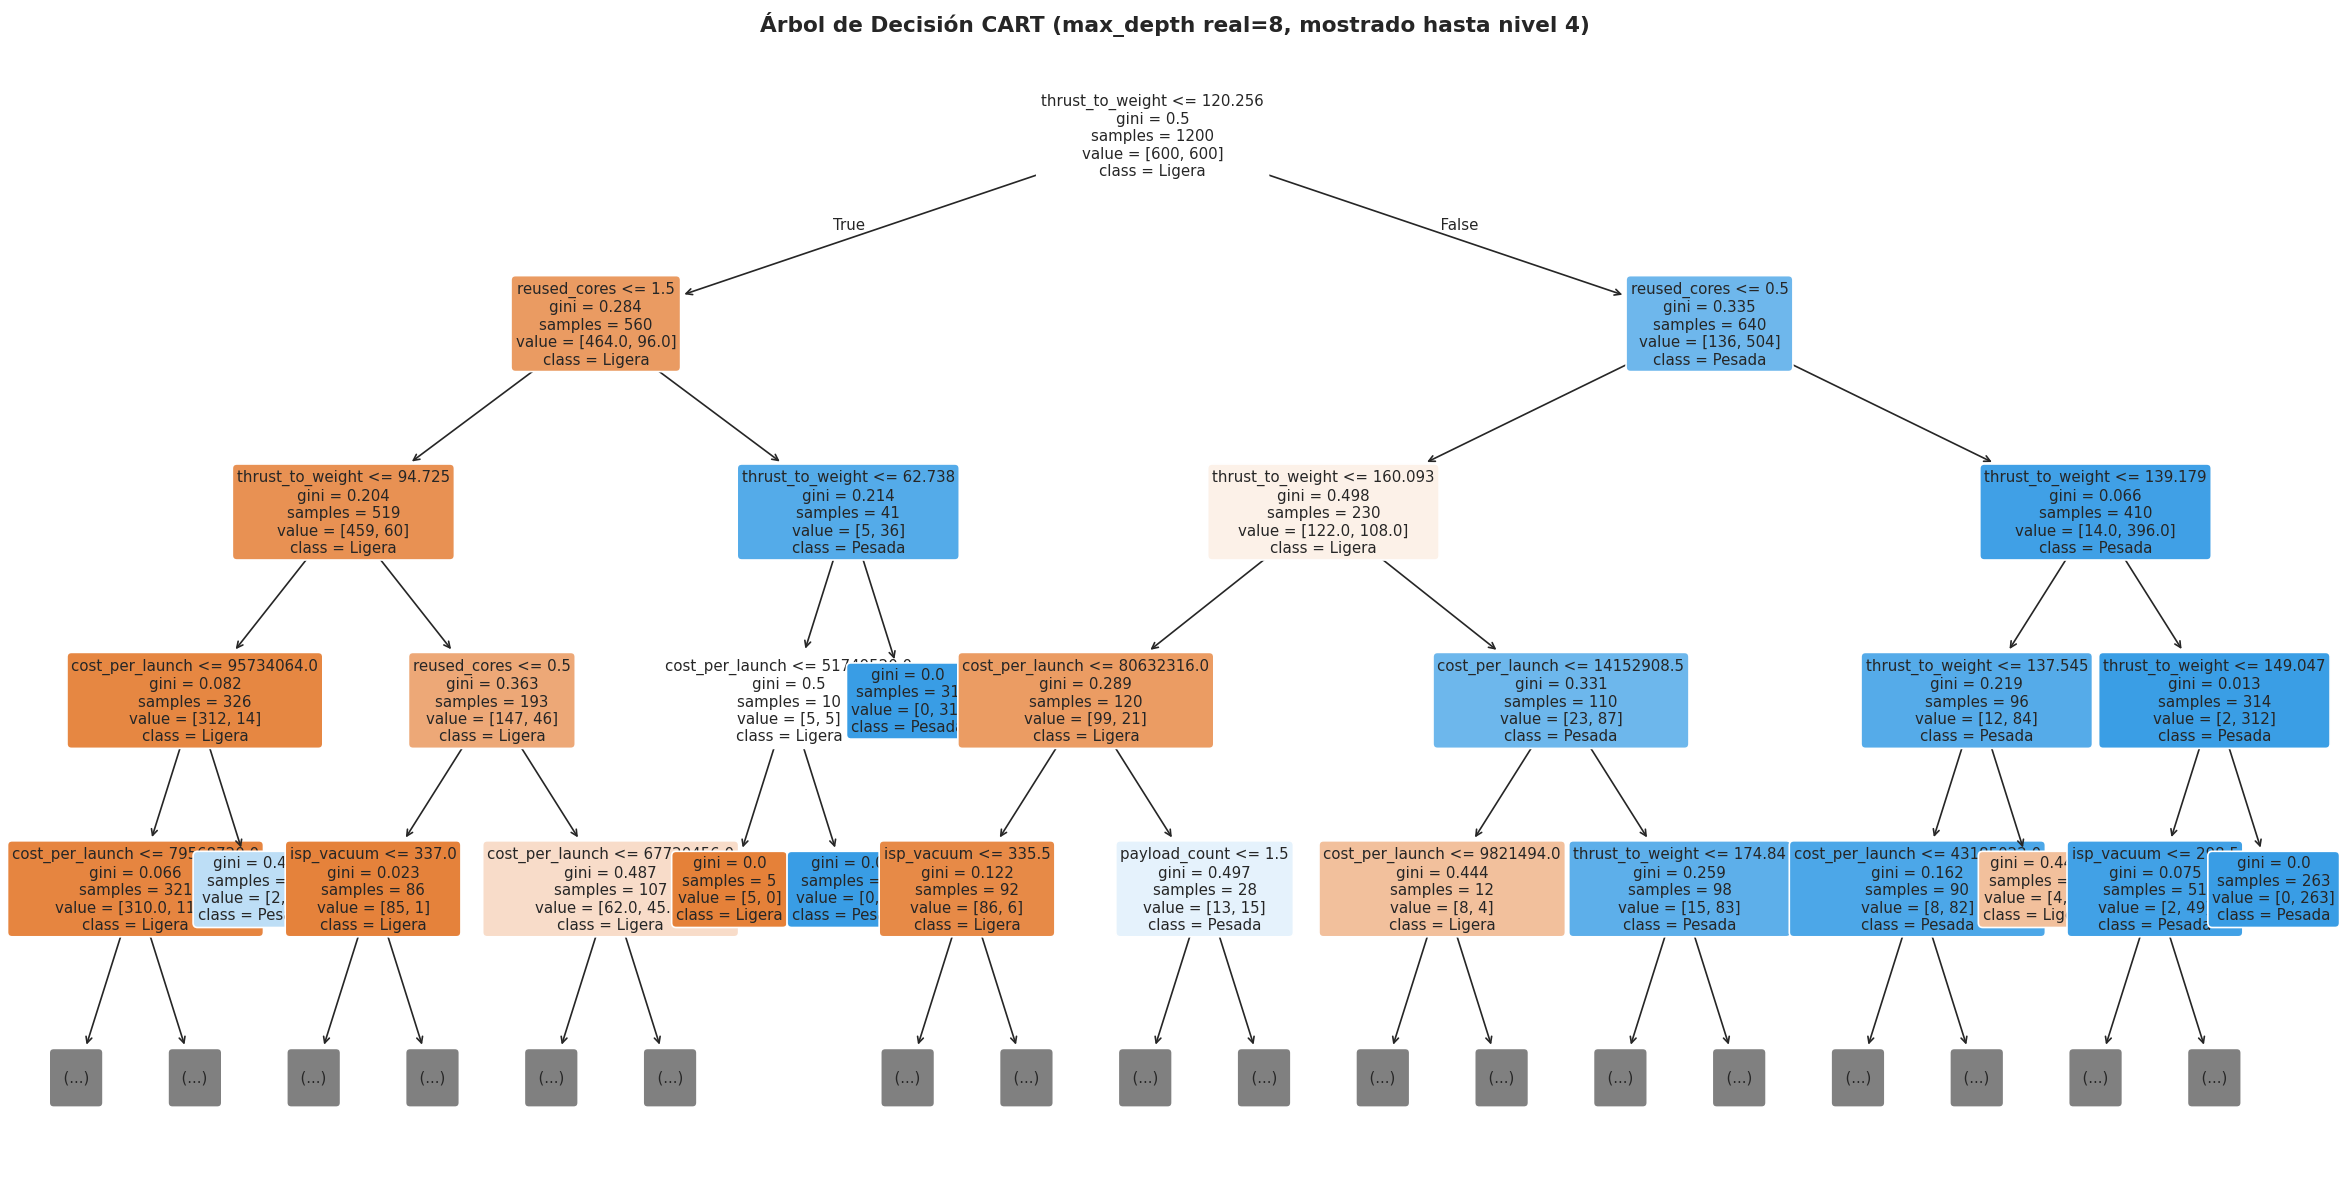


💡 Profundidad real del árbol entrenado: 8
   La visualización está truncada a 4 niveles por legibilidad.


In [14]:
# ── CELDA 14: Visualizar el árbol con max_depth óptimo ───────────────────────
modelo_opt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=mejor_depth,
    min_samples_split=10, min_samples_leaf=5,
    class_weight='balanced', random_state=42
)
X_tr_v, X_te_v, y_tr_v, y_te_v = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
modelo_opt.fit(X_tr_v, y_tr_v)

# Para visualización limitamos profundidad mostrada a 4 (legibilidad)
profundidad_visual = min(mejor_depth, 4)

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    modelo_opt,
    feature_names=features,
    class_names=['Ligera', 'Pesada'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=profundidad_visual,
    ax=ax
)
ax.set_title(
    f'Árbol de Decisión CART (max_depth real={mejor_depth}, mostrado hasta nivel {profundidad_visual})',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()
print(f"\n💡 Profundidad real del árbol entrenado: {mejor_depth}")
print(f"   La visualización está truncada a {profundidad_visual} niveles por legibilidad.")


## XIII. Tabla Final de Métricas


In [15]:
# ── CELDA 15: DataFrame resumen de métricas ──────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 70)
print(f"{'TABLA FINAL DE MÉTRICAS — SPACEX MISIÓN PESADA':^70}")
print("=" * 70)

display(resumen.style
    .background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
    .set_caption("Árbol de Decisión CART — Clasificación Binaria: Misión Pesada SpaceX")
)

print(f"\n📌 Comparación con regresión lineal:")
print("   · Regresión Lineal — predice valor continuo de total_payload_mass (kg).")
print("   · Árbol CART       — predice si la misión es Pesada (1) o Ligera (0).")
print(f"\n   Mejor max_depth encontrado: {mejor_depth}")


            TABLA FINAL DE MÉTRICAS — SPACEX MISIÓN PESADA            


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,1200,300,0.9100,0.9184,0.9000,0.9091,0.9555
Split 70/30,1050,450,0.9044,0.9136,0.8933,0.9034,0.9520
Split 60/40,900,600,0.8767,0.8669,0.8900,0.8783,0.9378



📌 Comparación con regresión lineal:
   · Regresión Lineal — predice valor continuo de total_payload_mass (kg).
   · Árbol CART       — predice si la misión es Pesada (1) o Ligera (0).

   Mejor max_depth encontrado: 8


## XIV. Conclusiones

### ¿Qué aprendimos con el Árbol CART sobre SpaceX?

| Aspecto | Observación |
|---------|------------|
| **Continuidad con regresión lineal** | Se reutilizó el mismo dataset sintético (`np.random.seed(42)`, N=1500) cambiando solo el target: de `total_payload_mass` (continuo) a `mision_pesada` (binario). |
| **Discretización por mediana** | El umbral en la mediana garantizó un balance natural ~50/50, ideal para clasificación. |
| **Resample demostrativo** | Como el balance ya era 50/50, el `resample` se aplicó como ejercicio demostrativo (en un escenario real con desbalance, habría sido fundamental). |
| **Sin escalado** | Los árboles CART son invariantes al escalado porque dividen en umbrales; esto simplifica el pipeline respecto a la Regresión Lineal con MinMaxScaler. |
| **Estabilidad entre splits** | Los tres splits arrojaron F1 similares → el modelo generaliza bien independientemente de la partición. |
| **Feature Importance** | `thrust_to_weight` y `reused_cores` resultaron los predictores más influyentes — consistente con sus coeficientes altos en la regresión lineal original. |
| **`class_weight='balanced'`** | Refuerzo adicional al `resample`, ajustando pesos durante el entrenamiento. |

### Comparación: Regresión Lineal vs Árbol CART (mismo dataset)

| | Regresión Lineal | Árbol CART |
|---|---|---|
| **Tipo de problema** | Regresión (Y continuo) | Clasificación binaria |
| **Variable objetivo** | `total_payload_mass` (kg) | `mision_pesada` (0/1) |
| **Escalado** | Requerido (MinMaxScaler) | No requerido |
| **Frontera de decisión** | Lineal | No lineal (por partes) |
| **Importancia de variables** | Coeficientes β (kg por unidad) | Reducción impureza Gini |
| **Métricas** | R², RMSE, MAE | Matriz de confusión, Precision, Recall, F1 |
| **Riesgo de overfitting** | Bajo | Alto si `max_depth` no se controla |
| **Interpretabilidad** | Ecuación lineal | Árbol de reglas if-else |

### Próximos pasos sugeridos

- **Validación cruzada (k-fold)** — estimación más confiable de las métricas que un único split.
- **Random Forest** — ensemble de árboles para reducir varianza y mejorar generalización.
- **Comparar con Regresión Logística** — modelo lineal de clasificación para contrastar con CART.
- **GridSearchCV** — búsqueda sistemática de hiperparámetros (`max_depth`, `min_samples_leaf`, etc).
- **Probar con umbrales distintos** — discretizar en cuartiles para problemas multiclase.
